In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/data_visualize/Dataaaaa.v1i.yolov8'

class_names = [
    'Boots', 'Gloves', 'No Boots', 'No Gloves',
    'No Reflective Jacket', 'No Safety Helmet',
    'Person', 'Reflective Jacket', 'Safety Helmet'
]
folder_mapping = {
    'train': ['train'],
    'valid': ['valid'],
    'test': ['test']
}

print("✅ Đã cấu hình xong đường dẫn và thư viện.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã cấu hình xong đường dẫn và thư viện.


In [ ]:
def process_data_counts():
    print(f"🔍 Đang quét dữ liệu tại: {base_path}")

    if not os.path.exists(base_path):
        print(f"❌ LỖI: Không tìm thấy thư mục '{base_path}'")
        return None, None
    subset_counts = {split: Counter() for split in folder_mapping.keys()}
    total_counts = Counter()
    for split_name, possible_names in folder_mapping.items():
        found_dir = None
        for name in possible_names:
            full_path = os.path.join(base_path, name)
            if os.path.exists(full_path):
                found_dir = full_path
                break

        if found_dir:
            print(f"🔹 Đang đọc tập '{split_name.upper()}'...", end=" ")
            label_dir = os.path.join(found_dir, 'labels')

            if os.path.exists(label_dir):
                files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
                print(f"-> {len(files)} files.")

                for file in files:
                    with open(os.path.join(label_dir, file), 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                try:
                                    cid = int(parts[0])
                                    if 0 <= cid < len(class_names):
                                        subset_counts[split_name][cid] += 1
                                        total_counts[cid] += 1
                                except ValueError: continue
            else:
                print(" -> ⚠️ Không có thư mục labels.")
        else:
            print(f"❌ Không tìm thấy tập '{split_name}'.")

    print("\n✅ Hoàn tất xử lý dữ liệu!")
    return subset_counts, total_counts

# --- CHẠY HÀM VÀ LƯU VÀO BIẾN TOÀN CỤC ---
global_subset_counts, global_total_counts = process_data_counts()

🔍 Đang quét dữ liệu tại: /content/drive/MyDrive/data_visualize/Dataaaaa.v1i.yolov8
🔹 Đang đọc tập 'TRAIN'... -> 9571 files.
🔹 Đang đọc tập 'VALID'... -> 2035 files.
🔹 Đang đọc tập 'TEST'... -> 987 files.

✅ Hoàn tất xử lý dữ liệu!



Class Name                | TRAIN    | VALID    | TEST     | TOTAL     
Safety Helmet             | 11099    | 2555     | 1124     | 14778     
Person                    | 9915     | 2103     | 988      | 13006     
Reflective Jacket         | 7806     | 1834     | 786      | 10426     
Gloves                    | 3752     | 797      | 229      | 4778      
Boots                     | 3584     | 713      | 228      | 4525      
No Reflective Jacket      | 3198     | 712      | 360      | 4270      
No Gloves                 | 3001     | 553      | 266      | 3820      
No Boots                  | 2406     | 443      | 215      | 3064      
No Safety Helmet          | 1252     | 267      | 115      | 1634      


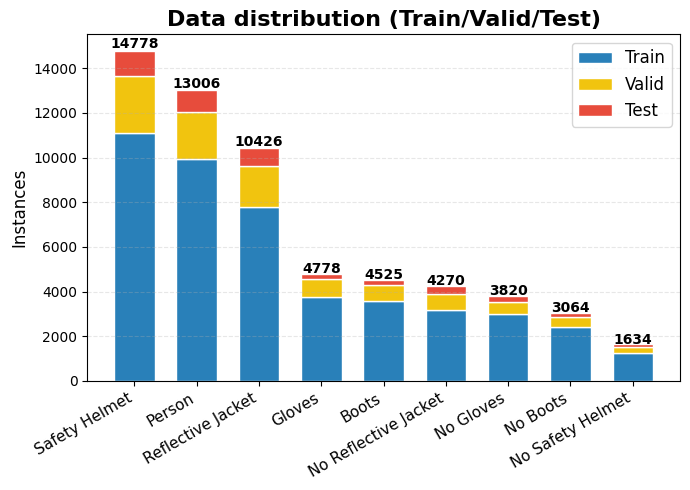

In [ ]:
def visualize_results(subset_counts, total_counts):
    if subset_counts is None or sum(total_counts.values()) == 0:
        print("❌ Chưa có dữ liệu để vẽ. Hãy chạy Ô 2 trước!")
        return
    print("\n" + "="*90)
    print(f"{'Class Name':<25} | {'TRAIN':<8} | {'VALID':<8} | {'TEST':<8} | {'TOTAL':<10}")
    print("="*90)
    sorted_classes = sorted(total_counts.items(), key=lambda x: x[1], reverse=True)
    sorted_ids = [x[0] for x in sorted_classes]
    for i in range(len(class_names)):
        if i not in sorted_ids: sorted_ids.append(i)

    for cid in sorted_ids:
        c_name = class_names[cid]
        c_train = subset_counts['train'][cid]
        c_val   = subset_counts['valid'][cid]
        c_test  = subset_counts['test'][cid]
        c_total = total_counts[cid]
        print(f"{c_name:<25} | {c_train:<8} | {c_val:<8} | {c_test:<8} | {c_total:<10}")
    labels = [class_names[i] for i in sorted_ids]
    d_train = [subset_counts['train'][i] for i in sorted_ids]
    d_valid = [subset_counts['valid'][i] for i in sorted_ids]
    d_test  = [subset_counts['test'][i] for i in sorted_ids]

    x = np.arange(len(labels))
    width = 0.65

    plt.figure(figsize=(7, 5)) # Kích thước ảnh
    p1 = plt.bar(x, d_train, width, label='Train', color='#2980b9', edgecolor='white')
    p2 = plt.bar(x, d_valid, width, bottom=d_train, label='Valid', color='#f1c40f', edgecolor='white')

    bottom_test = np.add(d_train, d_valid).tolist()
    p3 = plt.bar(x, d_test, width, bottom=bottom_test, label='Test', color='#e74c3c', edgecolor='white')
    plt.title('Data distribution (Train/Valid/Test)', fontsize=16, fontweight='bold')
    plt.ylabel('Instances', fontsize=12)
    plt.xticks(x, labels, rotation=30, ha='right', fontsize=11)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    for i in range(len(x)):
        total = d_train[i] + d_valid[i] + d_test[i]
        if total > 0:
            plt.text(i, total + (total * 0.01), str(total), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
visualize_results(global_subset_counts, global_total_counts)

In [ ]:
from PIL import Image
import tqdm # Thư viện thanh tiến trình

def process_image_resolutions():
    print(f"📏 Đang quét kích thước ảnh tại: {base_path}")
    print("⏳ Quá trình này có thể mất 1-2 phút do đọc file từ Drive...")

    widths = []
    heights = []

    # Duyệt qua các folder
    for split_name, possible_names in folder_mapping.items():
        found_dir = None
        for name in possible_names:
            full_path = os.path.join(base_path, name)
            if os.path.exists(full_path):
                found_dir = full_path
                break

        if found_dir:
            img_dir = os.path.join(found_dir, 'images') # Folder chứa ảnh
            if os.path.exists(img_dir):
                files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
                print(f"   -> Đang đọc {len(files)} ảnh trong tập '{split_name}'...")
                for file in files:
                    try:
                        with Image.open(os.path.join(img_dir, file)) as img:
                            w, h = img.size
                            widths.append(w)
                            heights.append(h)
                    except:
                        continue

    print(f"✅ Đã đọc xong kích thước của {len(widths)} ảnh!")
    return widths, heights
global_widths, global_heights = process_image_resolutions()

📏 Đang quét kích thước ảnh tại: /content/drive/MyDrive/data_visualize/Dataaaaa.v1i.yolov8
⏳ Quá trình này có thể mất 1-2 phút do đọc file từ Drive...
   -> Đang đọc 9572 ảnh trong tập 'train'...
   -> Đang đọc 2035 ảnh trong tập 'valid'...
   -> Đang đọc 987 ảnh trong tập 'test'...
✅ Đã đọc xong kích thước của 12594 ảnh!


🎨 Đang vẽ biểu đồ phân bố độ phân giải (Optimized)...


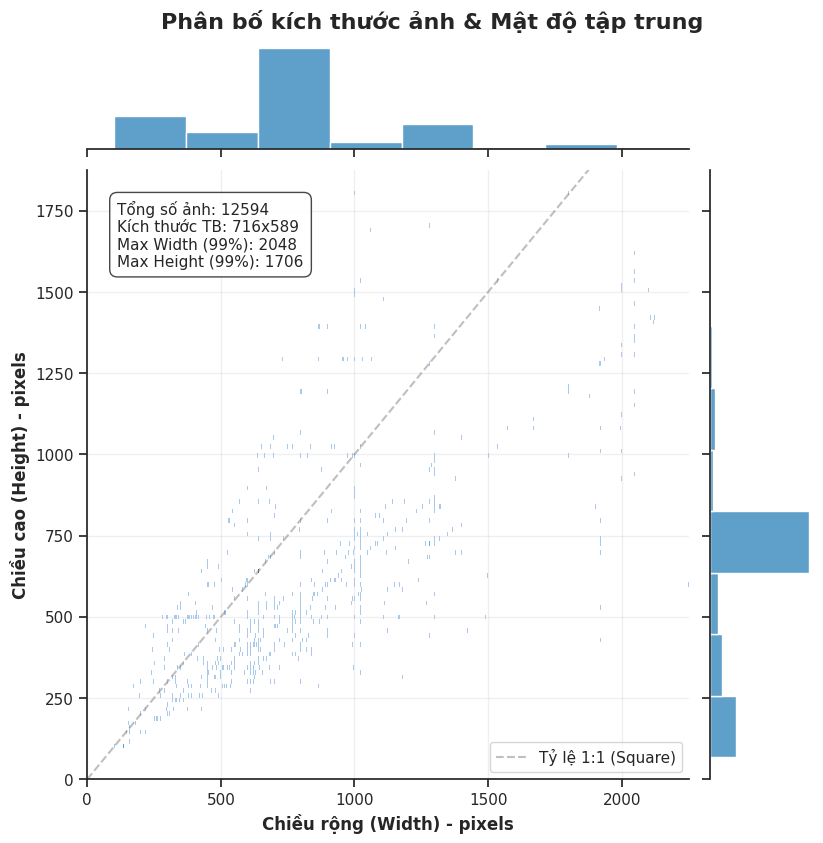

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def visualize_resolutions(widths, heights):
    if not widths:
        print("❌ Chưa có dữ liệu kích thước. Hãy chạy code quét ảnh trước!")
        return

    print("🎨 Đang vẽ biểu đồ phân bố độ phân giải (Optimized)...")

    # --- 1. XỬ LÝ SỐ LIỆU ĐỂ ZOOM CHUẨN ---
    # Lấy giới hạn chứa 99% dữ liệu để loại bỏ các ảnh quá to (outliers) làm hỏng biểu đồ
    max_w = np.percentile(widths, 99)
    max_h = np.percentile(heights, 99)

    # Cộng thêm chút lề (buffer) cho thoáng
    limit_w = max_w * 1.1
    limit_h = max_h * 1.1

    # --- 2. VẼ BIỂU ĐỒ ---
    sns.set_theme(style="ticks") # Style này nhìn sạch sẽ hơn whitegrid cho JointPlot

    # kind='hex' nhìn sẽ chuyên nghiệp hơn 'hist' cho dữ liệu mật độ
    # color="#2980b9" là màu xanh tiêu chuẩn, dễ nhìn
    g = sns.jointplot(x=widths, y=heights, kind="hist", height=8, color="#2980b9",
                      marginal_kws=dict(bins=30, fill=True))

    # --- 3. TINH CHỈNH TRỤC VÀ TỶ LỆ ---
    g.ax_joint.set_xlim(0, limit_w)
    g.ax_joint.set_ylim(0, limit_h)

    # Nhãn trục
    g.set_axis_labels("Chiều rộng (Width) - pixels", "Chiều cao (Height) - pixels", fontsize=12, fontweight='bold')
    g.fig.suptitle("Phân bố kích thước ảnh & Mật độ tập trung", fontsize=16, fontweight='bold', y=1.02)

    # --- 4. THÊM THÔNG TIN THỐNG KÊ ---
    avg_w = np.mean(widths)
    avg_h = np.mean(heights)
    count = len(widths)

    # Nội dung chú thích
    stats_text = (
        f"Tổng số ảnh: {count}\n"
        f"Kích thước TB: {int(avg_w)}x{int(avg_h)}\n"
        f"Max Width (99%): {int(max_w)}\n"
        f"Max Height (99%): {int(max_h)}"
    )

    # Vẽ khung chú thích ở góc trên bên trái (dùng tọa độ tương đối 0.05, 0.95)
    g.ax_joint.text(0.05, 0.95, stats_text, transform=g.ax_joint.transAxes,
                    fontsize=11, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='#333'))

    # --- 5. VẼ CÁC ĐƯỜNG TỶ LỆ THAM CHIẾU (Tùy chọn) ---
    # Đường chéo nét đứt thể hiện tỷ lệ 1:1 (Ảnh vuông)
    # Giúp bạn biết ảnh của mình thiên về hình chữ nhật ngang hay dọc
    x_ref = np.linspace(0, limit_w, 100)
    g.ax_joint.plot(x_ref, x_ref, '--', color='gray', alpha=0.5, label='Tỷ lệ 1:1 (Square)')
    g.ax_joint.legend(loc='lower right')

    plt.grid(alpha=0.3)
    plt.show()

# --- GỌI HÀM ---
# Lưu ý: Đảm bảo bạn đã chạy Ô 2 để có biến global_widths, global_heights
if 'global_widths' in globals() and global_widths is not None:
    visualize_resolutions(global_widths, global_heights)
else:
    print("⚠️ Biến 'global_widths' chưa tồn tại. Vui lòng chạy lại Ô 2 (process_image_resolutions) trước.")

🕵️‍♂️ BẮT ĐẦU QUÉT ẢNH LỖI VÀ MỜ (Ngưỡng mờ: 100)...

📂 Đang quét tập 'TRAIN' (9572 ảnh)...


100%|██████████| 9572/9572 [04:36<00:00, 34.59it/s]



📂 Đang quét tập 'VALID' (2035 ảnh)...


100%|██████████| 2035/2035 [00:52<00:00, 38.48it/s]



📂 Đang quét tập 'TEST' (987 ảnh)...


100%|██████████| 987/987 [00:22<00:00, 43.03it/s]



📊 KẾT QUẢ KIỂM TRA CHẤT LƯỢNG ẢNH
✅ Ảnh tốt (Good):      11737
🌫️ Ảnh mờ (Blurry):     857 (Dưới ngưỡng 100)
❌ Ảnh hỏng (Corrupt):  0


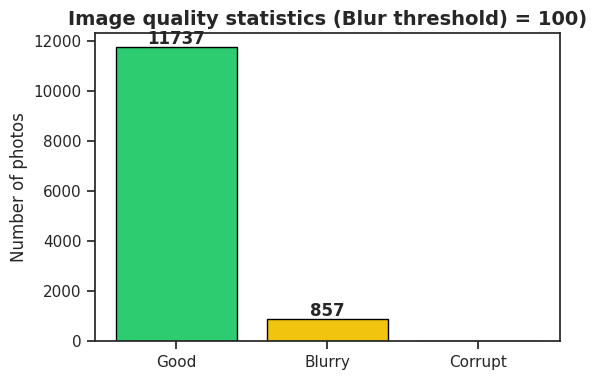


🌫️ VÍ DỤ ẢNH MỜ (Cân nhắc loại bỏ hoặc gán nhãn lại):
 - train/pos_1694_jpg.rf.7b31905c7f6a7023c9356c4dc4dab42e.jpg (Score: 96)
 - train/pos_533_jpg.rf.b22e57ab578cb75370d427fd070de2b2.jpg (Score: 97)
 - train/pos_348_jpg.rf.a9eacb09fb561e75ad66ded7595bfb34.jpg (Score: 51)
 - train/pos_1822_jpg.rf.6f6add11f0b778d50a833307e484587f.jpg (Score: 96)
 - train/ppe_0194_jpg.rf.87acdaa6641f7070e1f38ae91b1ed441.jpg (Score: 26)
 - train/ppe_0116_jpg.rf.a9aa7941f09cafa12c19a1df78b8cd3f.jpg (Score: 40)
 - train/ppe_0139_jpg.rf.00cacc7c722bdc4070bb961524eb67d8.jpg (Score: 14)
 - train/ppe_0237_jpg.rf.8000bf1f9e37fcd485a65f17d1cd8a7c.jpg (Score: 37)
 - train/ppe_0432_jpg.rf.3de045e1210ed07501c95f8333657f3b.jpg (Score: 69)
 - train/ppe_0314_jpg.rf.49d719e57a991799011333d4481ca829.jpg (Score: 73)


In [ ]:
import cv2
import os
import numpy as np
from PIL import Image
from tqdm import tqdm # Thanh tiến trình
import matplotlib.pyplot as plt

# --- CẤU HÌNH ---
base_path = '/content/drive/MyDrive/data_visualize/Dataaaaa.v1i.yolov8' # Thay đúng đường dẫn của bạn
blur_threshold = 100  # Ngưỡng độ mờ (Dưới 100 thường là mờ, càng cao càng khắt khe)

# Các folder cần quét
folders_to_scan = {
    'train': os.path.join(base_path, 'train', 'images'),
    'valid': os.path.join(base_path, 'valid', 'images'), # Hoặc 'val'
    'test':  os.path.join(base_path, 'test', 'images')
}

def check_image_quality():
    print(f"🕵️‍♂️ BẮT ĐẦU QUÉT ẢNH LỖI VÀ MỜ (Ngưỡng mờ: {blur_threshold})...")

    # Thống kê tổng
    stats = {
        'good': 0,
        'corrupt': 0,
        'blurry': 0,
        'missing': 0 # Không tìm thấy file
    }

    # Lưu danh sách file lỗi để bạn xem lại
    bad_files = {
        'corrupt': [],
        'blurry': []
    }

    # Duyệt qua từng folder (train/valid/test)
    for split, path in folders_to_scan.items():
        if not os.path.exists(path):
            print(f"⚠️ Không tìm thấy thư mục: {path}")
            continue

        files = [f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        print(f"\n📂 Đang quét tập '{split.upper()}' ({len(files)} ảnh)...")

        for file in tqdm(files):
            file_path = os.path.join(path, file)

            # --- BƯỚC 1: KIỂM TRA FILE HỎNG (CORRUPT) DÙNG PIL ---
            try:
                img_pil = Image.open(file_path)
                img_pil.verify() # Kiểm tra toàn vẹn file
            except (IOError, SyntaxError) as e:
                stats['corrupt'] += 1
                bad_files['corrupt'].append(f"{split}/{file}")
                continue # Bỏ qua bước kiểm tra mờ nếu ảnh đã hỏng

            # --- BƯỚC 2: KIỂM TRA ĐỘ MỜ (BLUR) DÙNG OPENCV ---
            img_cv = cv2.imread(file_path)
            if img_cv is None:
                stats['corrupt'] += 1
                bad_files['corrupt'].append(f"{split}/{file}")
                continue

            # Chuyển sang ảnh xám để tính toán
            gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

            # Tính phương sai của Laplacian (Laplacian Variance)
            # Giá trị càng CAO = Ảnh càng NÉT (nhiều cạnh)
            # Giá trị càng THẤP = Ảnh càng MỜ
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

            if blur_score < blur_threshold:
                stats['blurry'] += 1
                bad_files['blurry'].append(f"{split}/{file} (Score: {int(blur_score)})")
            else:
                stats['good'] += 1

    # --- TỔNG KẾT ---
    print("\n" + "="*50)
    print("📊 KẾT QUẢ KIỂM TRA CHẤT LƯỢNG ẢNH")
    print("="*50)
    print(f"✅ Ảnh tốt (Good):      {stats['good']}")
    print(f"🌫️ Ảnh mờ (Blurry):     {stats['blurry']} (Dưới ngưỡng {blur_threshold})")
    print(f"❌ Ảnh hỏng (Corrupt):  {stats['corrupt']}")
    print("="*50)

    # --- VẼ BIỂU ĐỒ ---
    labels = ['Good', 'Blurry', 'Corrupt']
    values = [stats['good'], stats['blurry'], stats['corrupt']]
    colors = ['#2ecc71', '#f1c40f', '#e74c3c']

    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=colors, edgecolor='black')
    plt.title(f'Image quality statistics (Blur threshold) = {blur_threshold})', fontsize=14, fontweight='bold')
    plt.ylabel('Number of photos')

    # Hiện số trên cột
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontweight='bold')

    plt.show()

    # --- IN DANH SÁCH FILE LỖI (NẾU CÓ) ---
    if stats['corrupt'] > 0:
        print("\n❌ DANH SÁCH ẢNH HỎNG (Cần xóa ngay):")
        for f in bad_files['corrupt'][:10]: print(f" - {f}")
        if len(bad_files['corrupt']) > 10: print(f"... và {len(bad_files['corrupt'])-10} ảnh khác.")

    if stats['blurry'] > 0:
        print("\n🌫️ VÍ DỤ ẢNH MỜ (Cân nhắc loại bỏ hoặc gán nhãn lại):")
        for f in bad_files['blurry'][:10]: print(f" - {f}")

check_image_quality()


🕵️‍♂️ ĐANG QUÉT LỖI BOUNDING BOX (LOGIC CHECK)...
   -> Đang kiểm tra 9571 file nhãn trong tập 'train'...


100%|██████████| 9571/9571 [01:56<00:00, 81.93it/s] 


   -> Đang kiểm tra 2035 file nhãn trong tập 'valid'...


100%|██████████| 2035/2035 [00:23<00:00, 87.06it/s] 


   -> Đang kiểm tra 987 file nhãn trong tập 'test'...


100%|██████████| 987/987 [00:06<00:00, 142.48it/s]



KẾT QUẢ KIỂM TRA LOGIC NHÃN (LABEL)
Tổng số file đã quét: 12593
Tổng số bounding box: 60288
------------------------------------------------------------
⚠️ Box quá nhỏ (Tiny < 0.05%):      501
⚠️ Box quá to (Giant > 98.0%):       53
⚠️ Box méo mó (Ratio > 8.0):           89
❌ Box lỗi tọa độ (Invalid Value):       0

👁️ Hiển thị ngẫu nhiên 3 ảnh bị lỗi: Box Quá Nhỏ (Tiny)


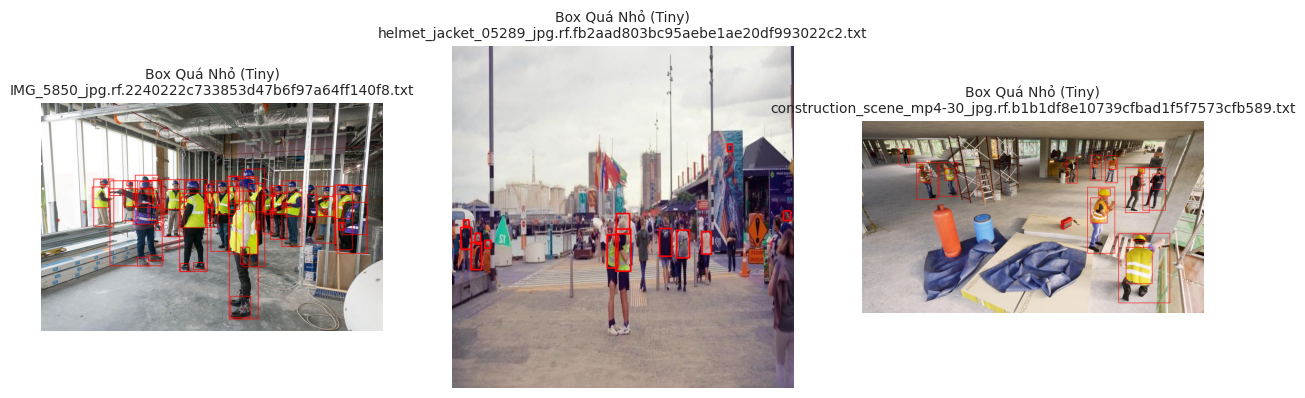


👁️ Hiển thị ngẫu nhiên 3 ảnh bị lỗi: Box Quá To (Giant)


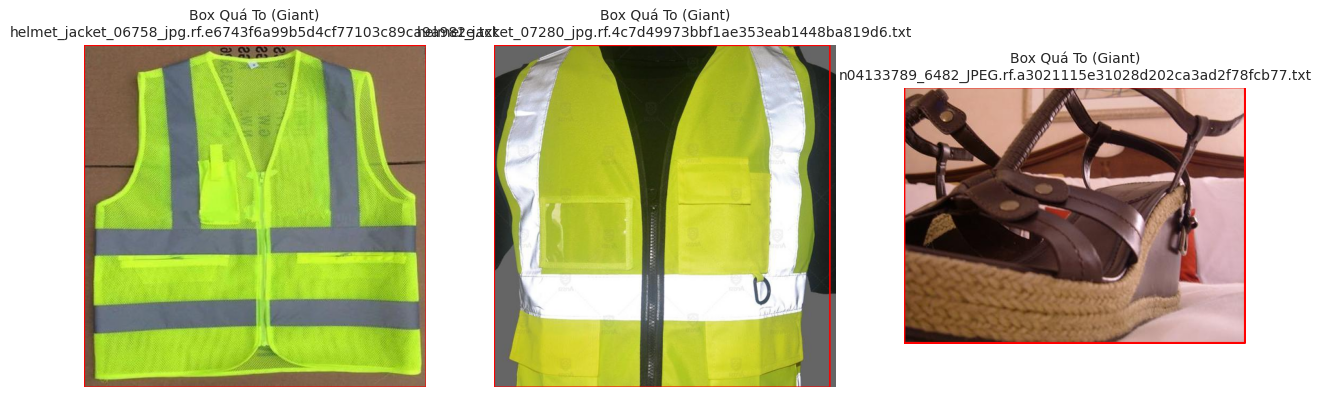

In [ ]:
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import random

# --- CẤU HÌNH ---
# Đường dẫn đến folder dataset của bạn
base_path = '/content/drive/MyDrive/data_visualize/Dataaaaa.v1i.yolov8'

# Ngưỡng cài đặt để bắt lỗi (Bạn có thể chỉnh lại)
THRESHOLDS = {
    'min_area': 0.0005,  # Box nhỏ hơn 0.05% diện tích ảnh -> Cảnh báo (quá bé)
    'max_area': 0.98,    # Box lớn hơn 98% diện tích ảnh -> Cảnh báo (quá to)
    'aspect_ratio': 8.0  # Tỷ lệ dài/rộng > 8 lần -> Cảnh báo (quá dẹt hoặc quá dài)
}

# Các folder cần quét
folders_to_scan = {
    'train': os.path.join(base_path, 'train', 'labels'),
    'valid': os.path.join(base_path, 'valid', 'labels'),
    'test':  os.path.join(base_path, 'test', 'labels')
}

def scan_bounding_box_errors():
    print("🕵️‍♂️ ĐANG QUÉT LỖI BOUNDING BOX (LOGIC CHECK)...")

    suspicious_files = {
        'tiny': [],         # Box quá nhỏ
        'giant': [],        # Box quá to
        'distorted': [],    # Tỷ lệ méo
        'invalid': [],      # Tọa độ sai (<0 hoặc >1)
        'duplicate': []     # Trùng nhau (Optional - code đơn giản chưa check kỹ IoU)
    }

    total_boxes = 0
    total_files = 0

    for split, path in folders_to_scan.items():
        if not os.path.exists(path): continue

        files = [f for f in os.listdir(path) if f.endswith('.txt')]
        print(f"   -> Đang kiểm tra {len(files)} file nhãn trong tập '{split}'...")

        for file in tqdm(files):
            file_path = os.path.join(path, file)
            total_files += 1

            with open(file_path, 'r') as f:
                lines = f.readlines()

            # Kiểm tra từng box trong file
            for i, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) < 5: continue

                try:
                    cls, x, y, w, h = map(float, parts)
                    total_boxes += 1

                    # 1. Kiểm tra tọa độ hợp lệ (YOLO phải từ 0-1)
                    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                        suspicious_files['invalid'].append(f"{split}/{file} (Line {i+1})")
                        continue

                    # 2. Kiểm tra diện tích (Area = w * h)
                    area = w * h
                    if area < THRESHOLDS['min_area']:
                        suspicious_files['tiny'].append(f"{split}/{file} (Class {int(cls)}: Area={area:.5f})")

                    if area > THRESHOLDS['max_area']:
                        suspicious_files['giant'].append(f"{split}/{file} (Class {int(cls)}: Area={area:.2f})")

                    # 3. Kiểm tra tỷ lệ khung hình (Aspect Ratio)
                    # Tránh chia cho 0
                    if w > 0 and h > 0:
                        ratio = max(w/h, h/w)
                        if ratio > THRESHOLDS['aspect_ratio']:
                            suspicious_files['distorted'].append(f"{split}/{file} (Class {int(cls)}: Ratio={ratio:.1f})")

                except ValueError:
                    continue

    # --- BÁO CÁO KẾT QUẢ ---
    print("\n" + "="*60)
    print("KẾT QUẢ KIỂM TRA LOGIC NHÃN (LABEL)")
    print("="*60)
    print(f"Tổng số file đã quét: {total_files}")
    print(f"Tổng số bounding box: {total_boxes}")
    print("-" * 60)
    print(f"⚠️ Box quá nhỏ (Tiny < {THRESHOLDS['min_area']*100}%):      {len(suspicious_files['tiny'])}")
    print(f"⚠️ Box quá to (Giant > {THRESHOLDS['max_area']*100}%):       {len(suspicious_files['giant'])}")
    print(f"⚠️ Box méo mó (Ratio > {THRESHOLDS['aspect_ratio']}):           {len(suspicious_files['distorted'])}")
    print(f"❌ Box lỗi tọa độ (Invalid Value):       {len(suspicious_files['invalid'])}")
    print("="*60)

    return suspicious_files

# --- HÀM VẼ ẢNH ĐỂ KIỂM TRA CÁC FILE BỊ BÁO LỖI ---
def visualize_suspicious_images(suspicious_list, error_type="Lỗi", num_show=3):
    if not suspicious_list:
        print(f"✅ Không có file nào bị lỗi '{error_type}'.")
        return

    print(f"\n👁️ Hiển thị ngẫu nhiên 3 ảnh bị lỗi: {error_type}")

    # Lấy ngẫu nhiên vài file để xem
    samples = random.sample(suspicious_list, min(len(suspicious_list), num_show))

    plt.figure(figsize=(15, 5))

    for idx, item in enumerate(samples):
        # item dạng: "train/image_01.txt (Class 0...)"
        # Cần tách lấy đường dẫn file ảnh
        path_part = item.split(' ')[0] # "train/image_01.txt"
        split_name, txt_name = path_part.split('/')
        img_name = txt_name.replace('.txt', '.jpg') # Giả sử ảnh là jpg

        # Thử tìm ảnh (jpg, png, jpeg)
        img_path_base = os.path.join(base_path, split_name, 'images', txt_name.replace('.txt', ''))

        final_img_path = None
        for ext in ['.jpg', '.png', '.jpeg']:
            if os.path.exists(img_path_base + ext):
                final_img_path = img_path_base + ext
                break

        if final_img_path:
            # Đọc ảnh và vẽ box
            img = cv2.imread(final_img_path)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h_img, w_img = img.shape[:2]

            # Đọc lại label để vẽ
            label_path = os.path.join(base_path, split_name, 'labels', txt_name)
            with open(label_path, 'r') as f:
                for line in f:
                    c, x, y, w, h = map(float, line.split())

                    # Chuyển sang pixel
                    x1 = int((x - w/2) * w_img)
                    y1 = int((y - h/2) * h_img)
                    x2 = int((x + w/2) * w_img)
                    y2 = int((y + h/2) * h_img)

                    # Vẽ khung đỏ
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

            plt.subplot(1, num_show, idx+1)
            plt.imshow(img)
            plt.title(f"{error_type}\n{txt_name}", fontsize=10)
            plt.axis('off')

    plt.show()

# --- CHẠY CHƯƠNG TRÌNH ---
bad_labels = scan_bounding_box_errors()

# Nếu muốn xem ảnh bị lỗi "Box quá nhỏ", bỏ comment dòng dưới:
if len(bad_labels['tiny']) > 0:
    visualize_suspicious_images(bad_labels['tiny'], "Box Quá Nhỏ (Tiny)")

# Nếu muốn xem ảnh bị lỗi "Box quá to", bỏ comment dòng dưới:
if len(bad_labels['giant']) > 0:
    visualize_suspicious_images(bad_labels['giant'], "Box Quá To (Giant)")